# Obtained derived functions from reconstructions

In this notebook we showcase how **CoRe** handles the reconstruction of a derived quantities using as input the mean and covariance matrix of observed quantities.

This example focuses on the case where the data are analyzed using Gaussian Process (GP), but the derived function module is able to work with any reconstruction method, as long as it returns the mean and covariance for the required quantities.

In [1]:
import sys,os
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from reconstruction_tools.GaussianProcess import GPCalculator

from copy    import deepcopy
from time    import time
from tqdm    import tqdm

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

In [2]:
def get_theory(coeffs):

    from numpy.polynomial import Polynomial
    
    p = Polynomial(coeffs)
    # Compute derivatives and integral using NumPy's built-in methods
    p_deriv1 = p.deriv(m=1)   # First derivative
    p_deriv2 = p.deriv(m=2)   # Second derivative
    p_integ  = p.integ(m=1)   # Antiderivative (integration constant C=0)
    results = {'f': lambda x: p(x),
               'd1': lambda x: p_deriv1(x),
               'd2': lambda x: p_deriv2(x),
               'int': lambda x: p_integ(x)}
    return results

# 1) Create data

First we create the observational data.

We assume here to have correlated (or uncorrelated) measurements of two quantities: $f(x)$ and $g(x)$

## Generating correlated data

In [3]:
Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 5

In [4]:
fiducial_func1 = {'a0': 3,
                  'a1': -1,
                  'a2': 5,
                  'a3': -0.1}

theory_model_func1 = get_theory(list(fiducial_func1.values()))

fiducial_func2 = {'a0': 0,
                  'a1': 1,
                  'a2': -2,
                  'a3':0.5}

theory_model_func2 = get_theory(list(fiducial_func2.values()))

In [5]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals_1 = theory_model_func1['f'](dataset['x'])
errors = abs(thvals_1)*err_fac/100
dataset['f1_err'] = errors

thvals_2 = theory_model_func2['f'](dataset['x'])
errors = abs(thvals_2)*err_fac/100
dataset['f2_err'] = errors

dataset['r(f1,f2)'] = np.random.uniform(0,1.,len(dataset))

In [6]:
covmat_func1 = pd.DataFrame(np.diag(errors*2),columns=['f1_{}'.format(ind) for ind in range(len(dataset['x']))])
covmat_func1.index = covmat_func1.columns

covmat_func2 = pd.DataFrame(np.diag(errors*2),columns=['f2_{}'.format(ind) for ind in range(len(dataset['x']))])
covmat_func2.index = covmat_func2.columns

cov_cross = np.diag([row['f1_err']*row['f2_err']*row['r(f1,f2)'] for ind,row in dataset.iterrows()])

joint_matrix = np.block([[covmat_func1.values,  cov_cross],
                         [cov_cross.T, covmat_func2.values]])

N = len(dataset)
labels = [f"f1_{i}" for i in range(N)] + [f"f2_{i}" for i in range(N)]
data_covmat = pd.DataFrame(joint_matrix, columns=labels, index=labels)

In [7]:
obsvec = np.random.multivariate_normal([v for v in thvals_1]+[v for v in thvals_2],data_covmat.values)

dataset['f1'] = obsvec[:len(dataset)]
dataset['f2'] = obsvec[len(dataset):]

dataset = dataset[['x','f1','f2','f1_err','f2_err']]

dataset

,x,f1,f2,f1_err,f2_err
0,1.736299,15.682247,-1.320529,0.790697,0.083797
1,1.108910,7.593835,-0.947108,0.395157,0.033432
2,0.888156,5.720121,-0.453600,0.299295,0.016959
3,1.009790,6.954558,-0.432799,0.349281,0.025737
4,0.602122,4.180366,-0.002411,0.209440,0.000692
5,1.536763,13.016830,-1.607907,0.645425,0.068594
6,0.589653,4.113990,-0.019552,0.206415,0.000161
7,1.848683,17.529653,-2.005062,0.880382,0.091376
8,0.102153,2.990812,-0.103627,0.147496,0.004091
9,0.330791,3.280872,0.288734,0.160635,0.006502


## Plot data

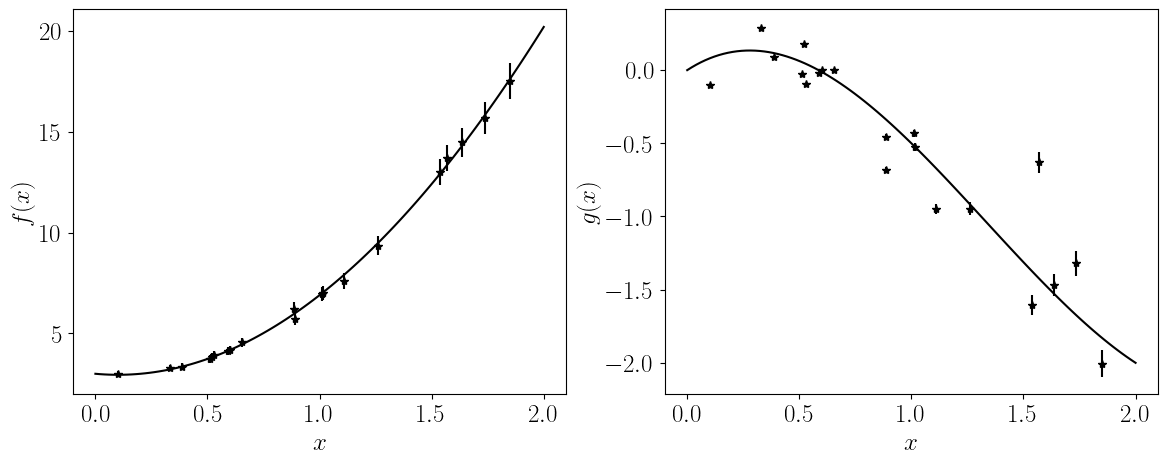

In [8]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=1,ncols=2,sharey=False,sharex=True,figsize=(14,5))
axes[0].plot(xplot,theory_model_func1['f'](xplot),color='black')
axes[0].errorbar(dataset['x'],dataset['f1'],yerr=dataset['f1_err'],color='black',ls='',marker='*')
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$f(x)$')

axes[1].plot(xplot,theory_model_func2['f'](xplot),color='black')
axes[1].errorbar(dataset['x'],dataset['f2'],yerr=dataset['f2_err'],color='black',ls='',marker='*')
axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r'$g(x)$');

# 2) Observable reconstruction

Here we reconstruct the two functions from the observational measurements. We work with GP in both the correlated and uncorrelated case

## Settings

In [9]:
N_recon = 5
xmin_recon = 0.1
xmax_recon = 1.8
x_recon = np.linspace(xmin_recon,xmax_recon,N_recon)

possible_derivatives = ['f','int','d1','d2']

kernel = 'RBF'

method = 'BAYESIAN'

## Reconstructions

In [10]:
all_reconstructions = {}

### Correlated

In [11]:
gp = GPCalculator(dataset,data_covmat,kernel_type=kernel)

In [12]:
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method=method,n_samples=100)

all_reconstructions['correlated'] = {'means': means,
                                     'covmat': joint_cov,
                                     'color': red}

print('GP ({}) done in {:.2f} s'.format(method,time()-tini))

Removed no burn in
GP (BAYESIAN) done in 222.07 s


### Uncorrelated

In [13]:
dataset_func1 = pd.DataFrame({'x': dataset['x'].values,
                              'f': dataset['f1'].values,
                              'f_err': dataset['f1_err'].values})

gp = GPCalculator(dataset_func1,covmat_func1,kernel_type=kernel)

tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method=method,n_samples=100)

all_reconstructions['fx'] = {'means': means,
                             'covmat': joint_cov,
                             'color': yellow}

print('GP ({}) done in {:.2f} s'.format(method,time()-tini))

Removed no burn in
GP (BAYESIAN) done in 266.52 s


In [14]:
dataset_func2 = pd.DataFrame({'x': dataset['x'].values,
                              'f': dataset['f2'].values,
                              'f_err': dataset['f2_err'].values})

gp = GPCalculator(dataset_func2,covmat_func2,kernel_type=kernel)

tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method=method,n_samples=100)

all_reconstructions['gx'] = {'means': means,
                             'covmat': joint_cov,
                             'color': yellow}

print('GP ({}) done in {:.2f} s'.format(method,time()-tini))

Removed no burn in
GP (BAYESIAN) done in 295.40 s


## Plot reconstruction

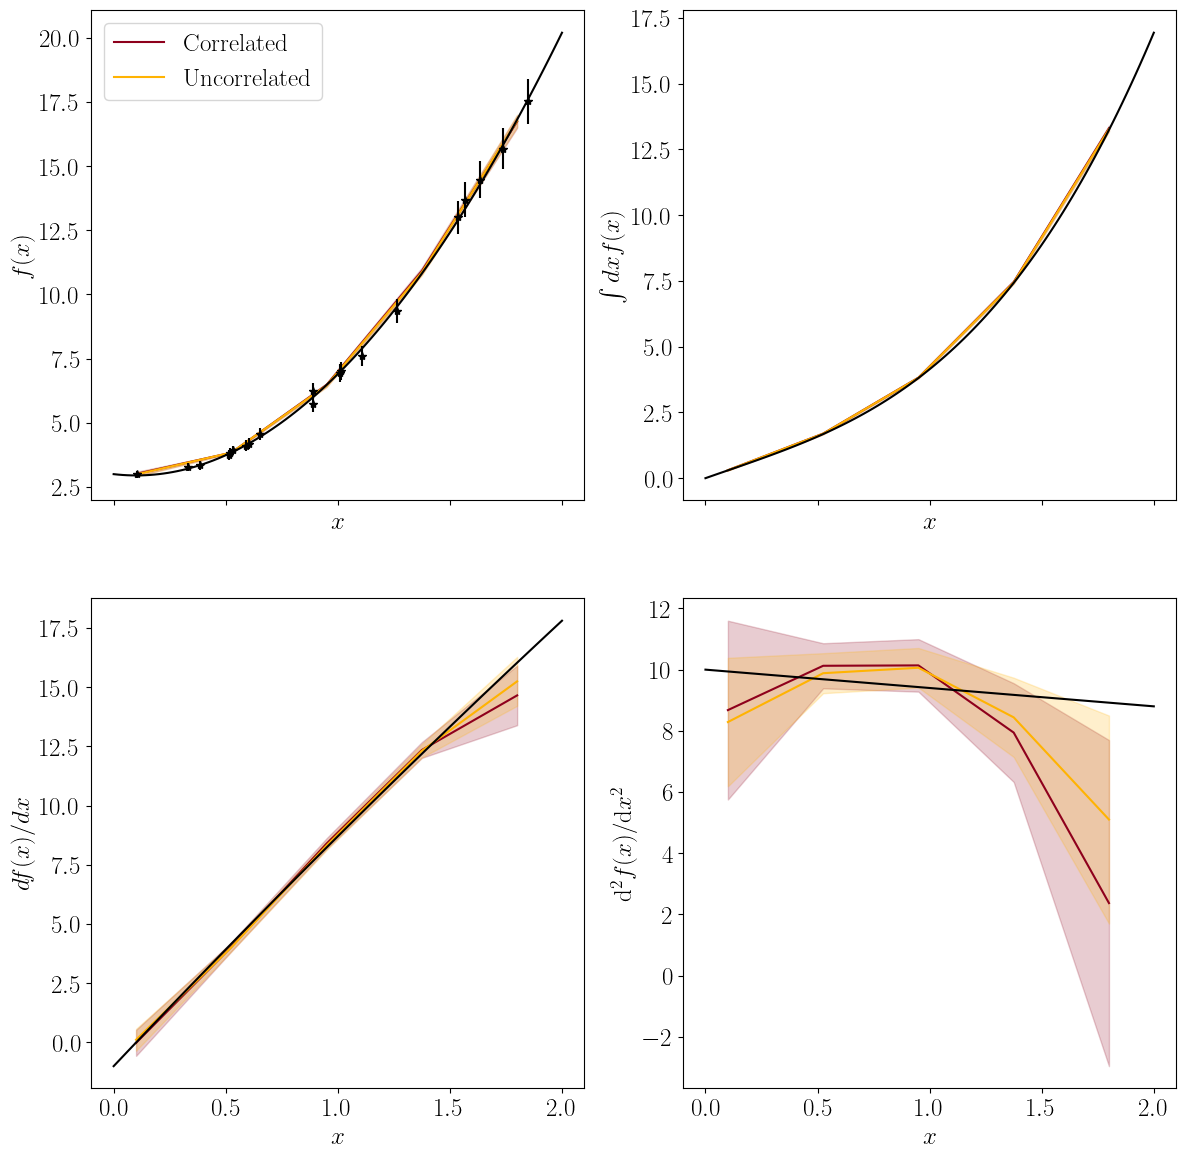

In [15]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = r'$f(x)$'
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int dx f(x)$'
    elif ind == 2:
        i = 1
        j = 0
        label = r'$df(x)/dx$'
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2f(x)$'+'/d'+r'$x^2$'

    df = all_reconstructions['correlated']['means']
    axes[i,j].fill_between(df['x'],df[deriv+'1']+df[deriv+'1_err'],df[deriv+'1']-df[deriv+'1_err'],alpha=0.2,
                           color=all_reconstructions['correlated']['color'])
    axes[i,j].plot(df['x'],df[deriv+'1'],color=all_reconstructions['correlated']['color'],label='Correlated')
    
    df = all_reconstructions['fx']['means']
    axes[i,j].fill_between(df['x'],df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2,
                            color=all_reconstructions['fx']['color'])
    axes[i,j].plot(df['x'],df[deriv],color=all_reconstructions['fx']['color'],label='Uncorrelated')
    
    axes[i,j].plot(xplot,theory_model_func1[deriv](xplot),color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv+'1'],yerr=dataset[deriv+'1_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(r'$x$')
    axes[i,j].set_ylabel(label)
    axes[0,0].legend(loc='best')

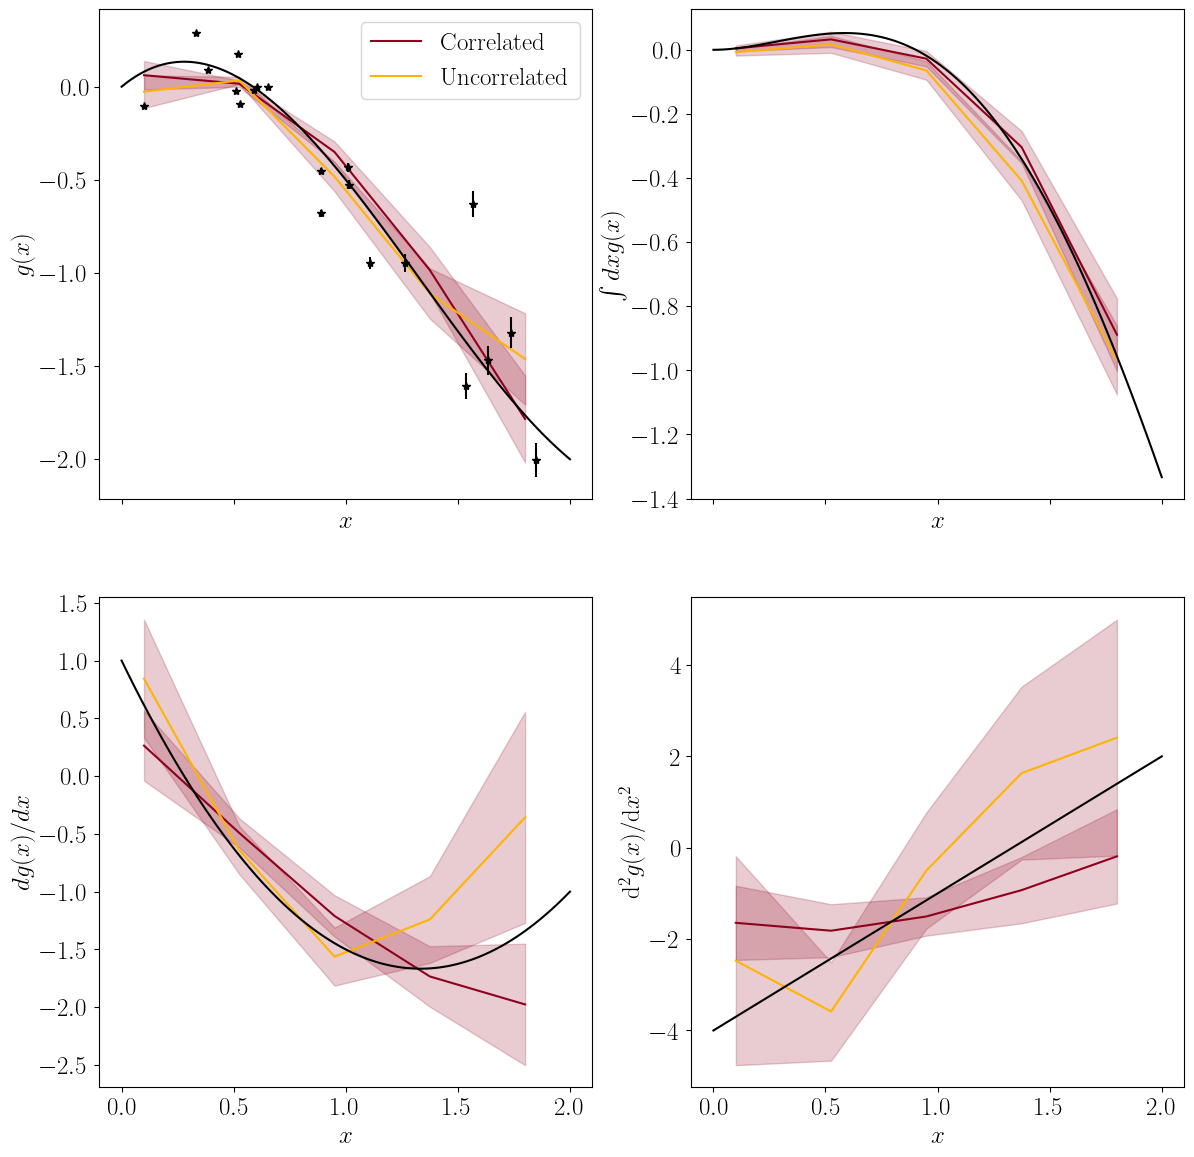

In [16]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = r'$g(x)$'
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int dx g(x)$'
    elif ind == 2:
        i = 1
        j = 0
        label = r'$dg(x)/dx$'
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2g(x)$'+'/d'+r'$x^2$'

    df = all_reconstructions['correlated']['means']
    axes[i,j].fill_between(df['x'],df[deriv+'2']+df[deriv+'2_err'],df[deriv+'2']-df[deriv+'2_err'],alpha=0.2,
                           color=all_reconstructions['correlated']['color'])
    axes[i,j].plot(df['x'],df[deriv+'2'],color=all_reconstructions['correlated']['color'],label='Correlated')
    
    df = all_reconstructions['gx']['means']
    axes[i,j].fill_between(df['x'],df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2,
                           color=all_reconstructions['correlated']['color'])
    axes[i,j].plot(df['x'],df[deriv],color=all_reconstructions['fx']['color'],label='Uncorrelated')
    
    axes[i,j].plot(xplot,theory_model_func2[deriv](xplot),color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv+'2'],yerr=dataset[deriv+'2_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(r'$x$')
    axes[i,j].set_ylabel(label)
    axes[0,0].legend(loc='best')

# 3) Obtain derived function

Once we have reconstructed our functions $f(x)$ and $g(x)$ from data, let's assume that our goal is to obtain a derived function

$$D(x)=g'(x)/f(x)$$

given that this includes the inverse of one of the functions, which is not a linear operation, the $D(x)$ will not be a GP and therefore we need to obtain its main and covariance through other means.

The `DerivedFunction` module, contained in `derived_function/reconstructor.py`, allows to obtain a generic derived function given a set of reconstructed mean and covariance for the primary reconstructions, and given a logic of how to combine them.

In [17]:
from derived_function.reconstructor import DerivedFunction

In [19]:
fiducial_primary = {'fx_f_{}'.format(ind): theory_model_func1['f'](x) for ind,x in enumerate(x_recon)}
fiducial_primary = fiducial_primary | {'gx_d1_{}'.format(ind): theory_model_func2['d1'](x) for ind,x in enumerate(x_recon)}

In [20]:
fiducial_recon = {'D_{}'.format(ind): (1+x_recon[ind])*theory_model_func2['d1'](x_recon[ind])/theory_model_func1['f'](x_recon[ind]) 
                  for ind in range(N_recon)}

## Method 1: Bayesian Sampling

The sampling approach treats the GP components at each point as stochastic parameters and uses a nested sampler (e.g., Nautilus) to explore the resulting distribution of the derived quantity.

### The Process
1. **Parameterization:** Each point $x_i$ for every requested GP component (e.g., $f(x_i)$ and $f'(x_i)$) is treated as a separate parameter in a high-dimensional space.
2. **Likelihood & Priors:**
   * **Priors:** Are centered on the GP mean with a user-defined $\sigma$-width.
   * **Likelihood:** Is defined by the GP covariance matrix: $\ln \mathcal{L} \propto -\frac{1}{2} (\vec{\theta} - \vec{\mu}_{GP})^T \mathbf{\Sigma}_{GP}^{-1} (\vec{\theta} - \vec{\mu}_{GP})$.
4. **Inference:** The sampler explores the space, and for every sample it draws, it calculates the derived quantity.

### Characteristics
* **Non-Gaussian Robustness:** Unlike the realizations method (see below), this approach captures the full, potentially non-Gaussian posterior of the derived function. If the relationship is highly non-linear, the error bars will correctly reflect the resulting asymmetry.
* **Computational Cost:** Much more expensive, as it requires running a full sampling chain in a parameter space of size $N_{comp} \times N_{points}$.
* **Honest Errors:** Provides the most rigorous propagation of uncertainty possible within the Bayesian framework.

> **Best for:** Final scientific results, especially when the derived quantity involves complex non-linear combinations where Gaussian error bars might be misleading.


In [21]:
method_dict = {'type': 'sampling',
               'options': {'sampler': 'Nautilus',
                           'run_options': 'poor'}}

In [22]:
results = {}

### Run correlated reconstruction

In [23]:
recon_dict = {'funcs': all_reconstructions['correlated']['means']}
cov_dict   = {'funcs': all_reconstructions['correlated']['covmat']}

reconstructor = DerivedFunction(recon_dict,cov_dict,method_dict,chatty=True)

derived_logic = lambda x,funcs_f1,funcs_d12: (1+x)*funcs_d12/funcs_f1
derived_name  = 'D'

results['Correlated'] = {'sample': reconstructor.run(derived_logic,derived_name,sigma_width=5),
                         'color': red}

Sampling GP components: ['funcs_f1', 'funcs_d12']
Loaded prior into Nautilus with dimension 10
Prior keys:  ['funcs_f1_0', 'funcs_f1_1', 'funcs_f1_2', 'funcs_f1_3', 'funcs_f1_4', 'funcs_d12_0', 'funcs_d12_1', 'funcs_d12_2', 'funcs_d12_3', 'funcs_d12_4']
Starting to sample with Nautilus...
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 26     | 1        | 2        | 19904    | N/A    | 10034 | -16.82   
NAUTILUS SAMPLING FINISHED
Removed no burn in


### Run uncorrelated reconstruction

In [24]:
recon_dict = {k: v['means'] for k,v in all_reconstructions.items() if k in ['fx','gx']}
cov_dict   = {k: v['covmat'] for k,v in all_reconstructions.items() if k in ['fx','gx']}

reconstructor = DerivedFunction(recon_dict,cov_dict,method_dict,chatty=True)

derived_logic = lambda x,fx_f,gx_d1: (1+x)*gx_d1/fx_f
derived_name  = 'D'

results['Uncorrelated'] = {'sample': reconstructor.run(derived_logic,derived_name,sigma_width=5),
                           'color': yellow}

Sampling GP components: ['fx_f', 'gx_d1']
Loaded prior into Nautilus with dimension 10
Prior keys:  ['fx_f_0', 'fx_f_1', 'fx_f_2', 'fx_f_3', 'fx_f_4', 'gx_d1_0', 'gx_d1_1', 'gx_d1_2', 'gx_d1_3', 'gx_d1_4']
Starting to sample with Nautilus...
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 23     | 1        | 2        | 18880    | N/A    | 10002 | -14.95   
NAUTILUS SAMPLING FINISHED
Removed no burn in


### Plotting reconstructed function points

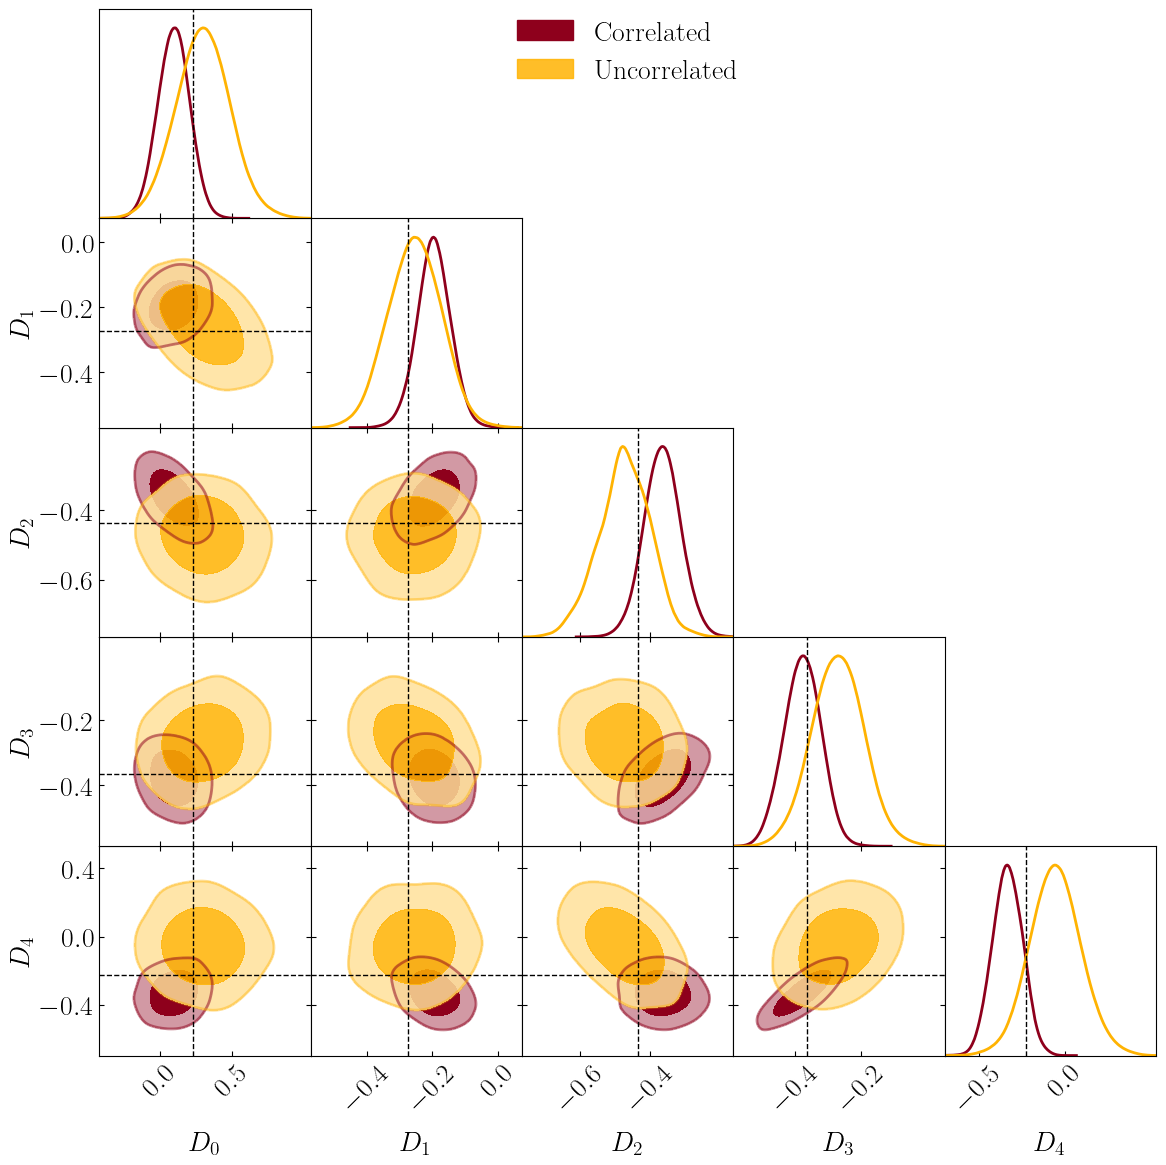

In [25]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot([val['sample'] for val in results.values()],list(fiducial_recon.keys()),
                filled=True,contour_lws=2,contour_colors=[val['color'] for val in results.values()],
                legend_labels=list(results.keys()),
                markers=fiducial_recon
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

### Plotting full reconstructed function

In [26]:
for method in ['Correlated','Uncorrelated']:
    sample = results[method]['sample']
    results[method]['reconstruction'] = pd.DataFrame({'x': x_recon})
    results[method]['reconstruction']['value'] = sample.getMeans()[2*N_recon:]
    results[method]['reconstruction']['error'] = np.sqrt(sample.getVars()[2*N_recon:])

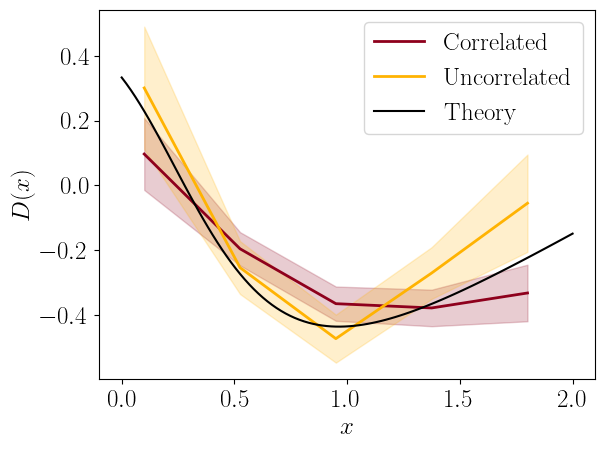

In [28]:
xplot = np.linspace(xmin,xmax,100)

plt.figure()
for method in ['Correlated','Uncorrelated']:
    reconstruction = results[method]['reconstruction']
    plt.fill_between(reconstruction['x'],reconstruction['value']+reconstruction['error'],
                     reconstruction['value']-reconstruction['error'],alpha=0.2,color=results[method]['color'])
    plt.plot(reconstruction['x'],reconstruction['value'],lw=2,color=results[method]['color'],label=method)
plt.plot(xplot,(1+xplot)*theory_model_func2['d1'](xplot)/theory_model_func1['f'](xplot),color='black',label='Theory')
plt.xlabel(r'$x$')
plt.ylabel(r'$D(x)$')
plt.legend(loc='best');

## Method 2: Monte Carlo Realizations

The realizations approach propagates uncertainty by drawing a set of $N$ random functional curves from the joint Gaussian distribution defined by the reconstruction.

### The Process
1. **Generating Curves:** The code draws $N_{reals}$ global realizations from the multivariate Gaussian distribution $\mathcal{N}(\vec{\mu}_{GP}, \mathbf{\Sigma}_{GP})$. Each realization is a smooth curve that represents a "possible" version of the underlying physics.
2. **Deterministic Mapping:** For each realization, the user-defined `derived_logic` is applied at every point $x$. This transforms the $N_{reals}$ GP curves into $N_{reals}$ derived curves.
3. **Statistical Summary:** The class computes the sample mean and the full joint covariance matrix of these derived curves.

### Characteristics
* **Gaussian Approximation:** The final result is condensed back into a Gaussian distribution (Mean + Covariance), even if the derived logic was non-linear.
* **Speed:** Generally faster than full sampling for complex functions.
* **Global Consistency:** Because it draws full curves, it naturally maintains the smoothness and correlations inherent in the GP.

> **Best for:** Quantities where the derived logic is relatively linear or where a Gaussian approximation of the final result is sufficient.

In [29]:
method_dict = {'type': 'realizations',
               'options': {'Nreals': 1000,
                           'Nsamples': 10000}}

In [30]:
real_results = {}

### Correlated

In [31]:
recon_dict = {'funcs': all_reconstructions['correlated']['means']}
cov_dict   = {'funcs': all_reconstructions['correlated']['covmat']}

reconstructor = DerivedFunction(recon_dict,cov_dict,method_dict,chatty=True)

derived_logic = lambda x,funcs_f1,funcs_d12: (1+x)*funcs_d12/funcs_f1
derived_name  = 'D'

real_results['Correlated'] = {'sample': reconstructor.run(derived_logic,derived_name),
                              'color': red}

Removed no burn in


### Uncorrelated

In [32]:
recon_dict = {k: v['means'] for k,v in all_reconstructions.items() if k in ['fx','gx']}
cov_dict   = {k: v['covmat'] for k,v in all_reconstructions.items() if k in ['fx','gx']}

reconstructor = DerivedFunction(recon_dict,cov_dict,method_dict,chatty=True)

derived_logic = lambda x,fx_f,gx_d1: (1+x)*gx_d1/fx_f
derived_name  = 'D'

real_results['Uncorrelated'] = {'sample': reconstructor.run(derived_logic,derived_name),
                                'color': yellow}

Removed no burn in


### Plotting reconstructed function points

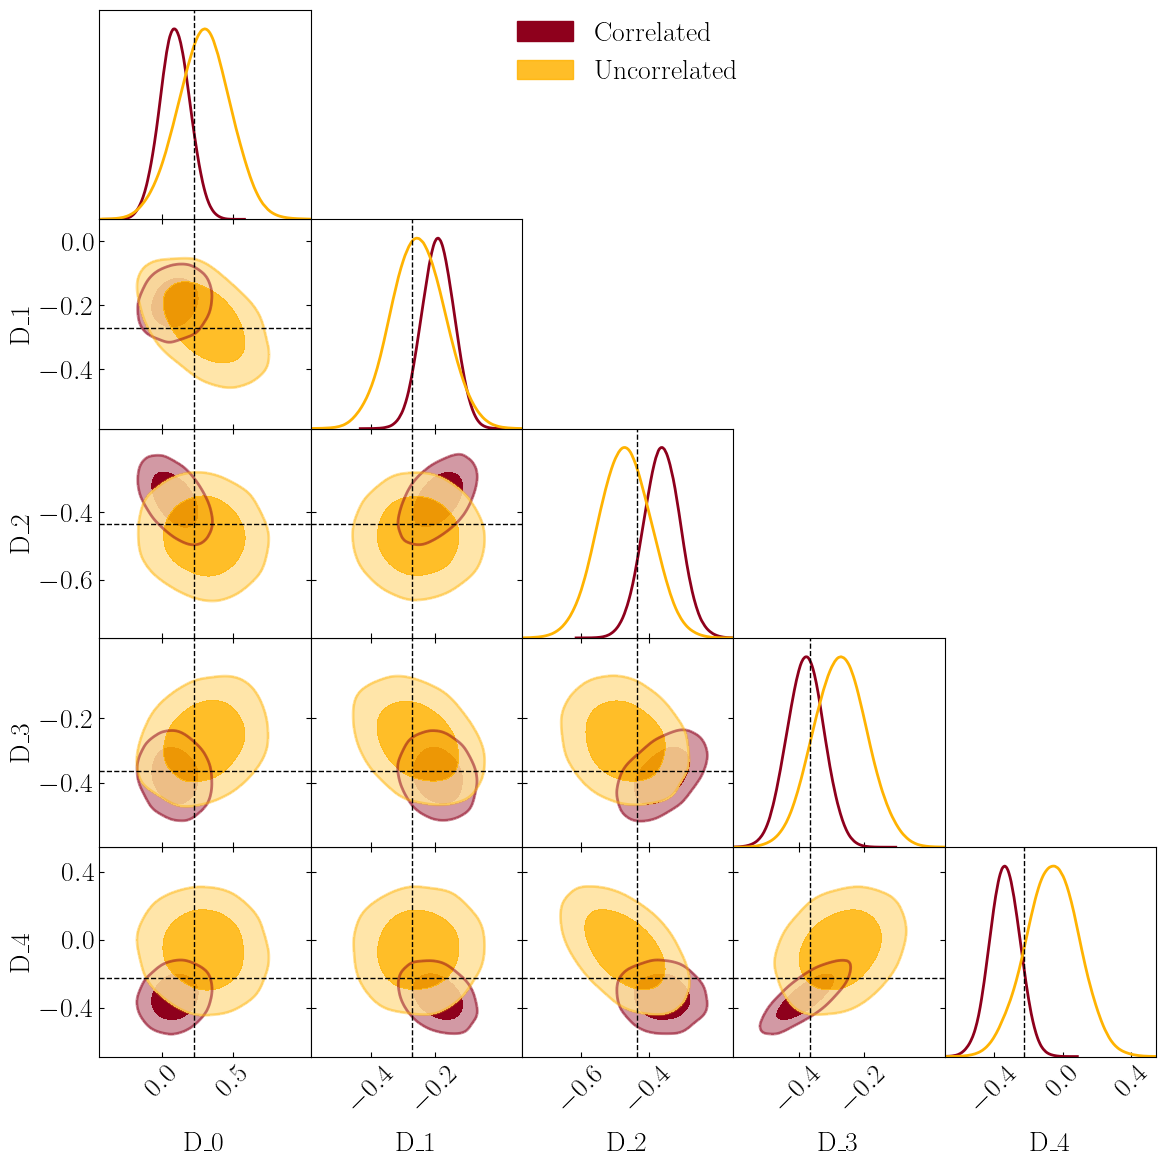

In [33]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot([val['sample'] for val in real_results.values()],list(fiducial_recon.keys()),
                filled=True,contour_lws=2,contour_colors=[val['color'] for val in real_results.values()],
                legend_labels=list(real_results.keys()),
                markers=fiducial_recon
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

### Plotting full reconstructed function

In [34]:
for method in ['Correlated','Uncorrelated']:
    sample = real_results[method]['sample']
    real_results[method]['reconstruction'] = pd.DataFrame({'x': x_recon}) #generilize!!!!
    real_results[method]['reconstruction']['value'] = sample.getMeans()
    real_results[method]['reconstruction']['error'] = np.sqrt(sample.getVars())

In [ ]:
xplot = np.linspace(xmin,xmax,100)

plt.figure()
for method in ['Correlated','Uncorrelated']:
    reconstruction = real_results[method]['reconstruction']
    plt.fill_between(reconstruction['x'],reconstruction['value']+reconstruction['error'],
                     reconstruction['value']-reconstruction['error'],alpha=0.2,color=real_results[method]['color'])
    plt.plot(reconstruction['x'],reconstruction['value'],lw=2,color=real_results[method]['color'],label=method)
plt.plot(xplot,(1+xplot)*theory_model_func2['d1'](xplot)/theory_model_func1['f'](xplot),color='black',label='Theory')
plt.xlabel(r'$x$')
plt.ylabel(r'$D(x)$')
plt.legend(loc='best');

## Method comparison

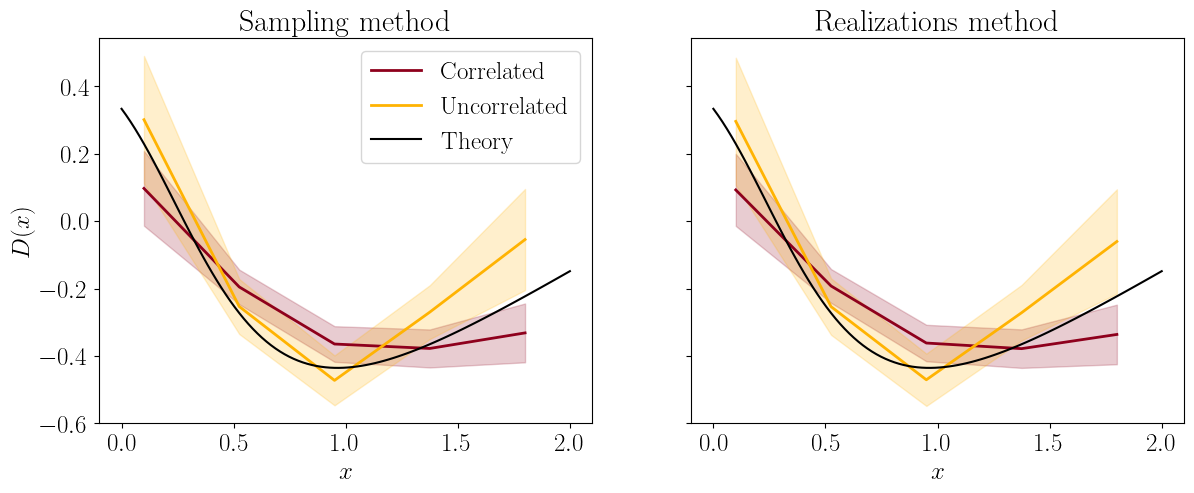

In [35]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=1,ncols=2,sharey=True,sharex=True,figsize=(14,5))

axes[0].set_title('Sampling method')
axes[1].set_title('Realizations method')

for method in ['Correlated','Uncorrelated']:
    reconstruction = results[method]['reconstruction']
    axes[0].fill_between(reconstruction['x'],reconstruction['value']+reconstruction['error'],
                         reconstruction['value']-reconstruction['error'],alpha=0.2,color=results[method]['color'])
    axes[0].plot(reconstruction['x'],reconstruction['value'],lw=2,color=results[method]['color'],label=method)
    
    reconstruction = real_results[method]['reconstruction']
    axes[1].fill_between(reconstruction['x'],reconstruction['value']+reconstruction['error'],
                         reconstruction['value']-reconstruction['error'],alpha=0.2,color=real_results[method]['color'])
    axes[1].plot(reconstruction['x'],reconstruction['value'],lw=2,color=real_results[method]['color'],label=method)
axes[1].plot(xplot,(1+xplot)*theory_model_func2['d1'](xplot)/theory_model_func1['f'](xplot),color='black',label='Theory')
axes[1].set_xlabel(r'$x$')
axes[0].plot(xplot,(1+xplot)*theory_model_func2['d1'](xplot)/theory_model_func1['f'](xplot),color='black',label='Theory')
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$D(x)$')
axes[0].legend(loc='best');